# 🚀 Lab 22: Statistical Visuals with Seaborn

### 📘 Lab Overview
In this lab, you will learn how to create **statistical visualizations using Seaborn**, one of the most powerful Python libraries for data visualization. You will build histograms, boxplots, and violin plots, then use Seaborn’s grouping features such as `hue`, `row`, and `col` to compare categories and create multi-panel statistical views.

You will work with the built-in **Titanic dataset**, which is widely used for learning data analysis and visualization. By the end of the lab, you will be able to visualize distributions, identify outliers, compare groups, and interpret patterns from real-world data.

## 🎯 Objectives
By the end of this lab, students will be able to:
* Create histograms to visualize numerical data distributions using Seaborn
* Generate boxplots to identify quartiles, medians, spread, and outliers
* Construct violin plots to display both summary statistics and distribution density
* Use the `hue` parameter for categorical grouping in Seaborn charts
* Use the `row` and `col` parameters for multi-panel subplot grids
* Load and analyze built-in datasets from the Seaborn library
* Apply statistical visualization techniques to real-world datasets
* Interpret histograms, boxplots, and violin plots for meaningful data insights

## 🧰 Prerequisites
Before starting this lab, students should have:
* Basic understanding of Python programming concepts
* Familiarity with Python data types such as lists and dictionaries
* Basic knowledge of pandas DataFrames
* Understanding of simple statistical concepts like mean, median, quartiles, and outliers
* Previous experience with Matplotlib is helpful but not required

## ⚙️ Environment Setup
Google Colab usually includes Seaborn, pandas, Matplotlib, and NumPy already installed. We will verify the environment and ensure all libraries are up to date.

In [1]:
# Install or update libraries if necessary
# We use %pip which is the recommended way to install packages in Colab
%pip install -U seaborn pandas matplotlib numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 80.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 56.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 54.3 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
      Successfully uninstalled matplotlib-3.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the sourc

## 💡 What You Are Going to Do
In simple words, this lab teaches you how to **look at data visually** and understand what it is trying to tell you.

We will explore how to see the spread of values, compare different groups (like survivors vs. non-survivors), and use advanced grids to see multiple dimensions of data at once.

# Task 1: Environment Setup and Data Loading

### 🐣 ELI10: Getting our tools ready
Before we start building charts, we need to bring our "toolbox" (libraries) into the notebook and get the data we want to study (the Titanic passenger list).

In [2]:
# Import essential libraries
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Set Seaborn style for cleaner visuals
# 'whitegrid' adds horizontal lines which help in reading values
sns.set_style("whitegrid")

# Set a default figure size for all charts to ensure they are readable
plt.rcParams["figure.figsize"] = (10, 6)

# Display library versions as requested
print(f"Seaborn version: {sns.__version__}")
print(f"Matplotlib version: {matplotlib.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Seaborn version: 0.13.2
Matplotlib version: 3.10.0
Pandas version: 3.0.2
NumPy version: 2.0.2


## 📦 Loading the Dataset
We will use the famous Titanic dataset. It contains information about passengers, such as their age, class, and whether they survived.

In [3]:
# Load the Titanic dataset directly from Seaborn's built-in repository
titanic = sns.load_dataset("titanic")

# Display basic information to understand the structure of our data
print("Dataset shape:", titanic.shape)
print("\nFirst 5 rows:")
display(titanic.head())

print("\nDataset info:")
titanic.info()

print("\nBasic statistics:")
display(titanic.describe(include="all"))

Dataset shape: (891, 15)

First 5 rows:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True



Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 100.4 KB

Basic statistics:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 🔍 Explore Available Columns
It's important to know what each column means before we start plotting.

In [4]:
# Print column descriptions to act as a reference guide
print("Available columns:")
for col in titanic.columns:
    print(f"- {col}")

print("\nKey Column Meanings:")
print("- survived: 0 = No, 1 = Yes")
print("- pclass: Ticket class (1 = 1st, 2 = 2nd, 3 = 3rd)")
print("- fare: Passenger fare (how much they paid)")
print("- who: man, woman, or child")

Available columns:
- survived
- pclass
- sex
- age
- sibsp
- parch
- fare
- embarked
- class
- who
- adult_male
- deck
- embark_town
- alive
- alone

Key Column Meanings:
- survived: 0 = No, 1 = Yes
- pclass: Ticket class (1 = 1st, 2 = 2nd, 3 = 3rd)
- fare: Passenger fare (how much they paid)
- who: man, woman, or child


# Task 2: Creating Histograms

### 🐣 ELI10: The "How Many" Chart
A histogram is like a series of buckets. We put data points into buckets based on their value (like age 0-10, 10-20) and see which bucket is the fullest.

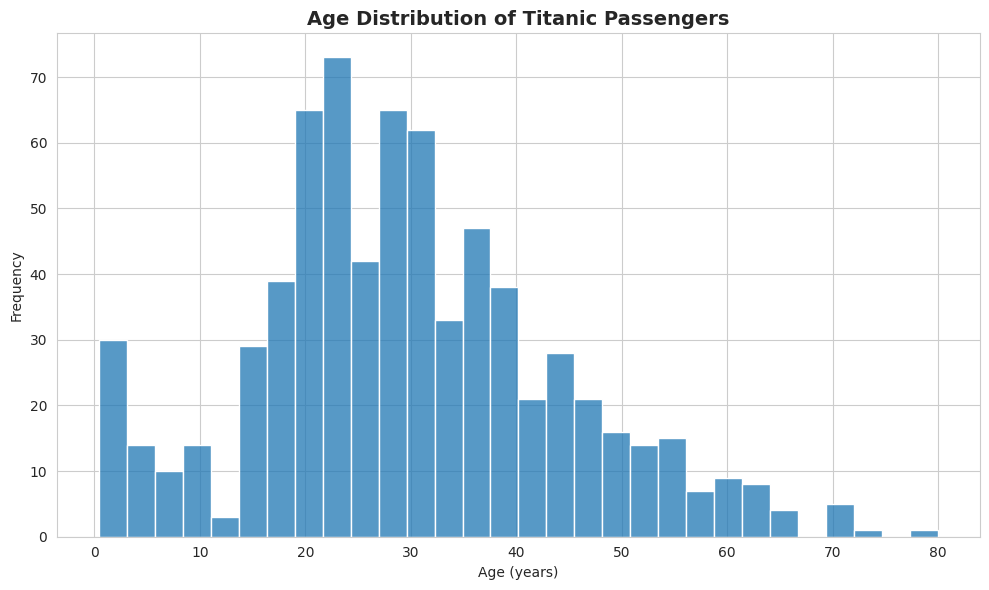

In [5]:
# Subtask 2.1: Basic Histogram
# We use sns.histplot to see how ages are distributed
plt.figure(figsize=(10, 6))
sns.histplot(data=titanic, x="age", bins=30)

plt.title("Age Distribution of Titanic Passengers", fontsize=14, fontweight="bold")
plt.xlabel("Age (years)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

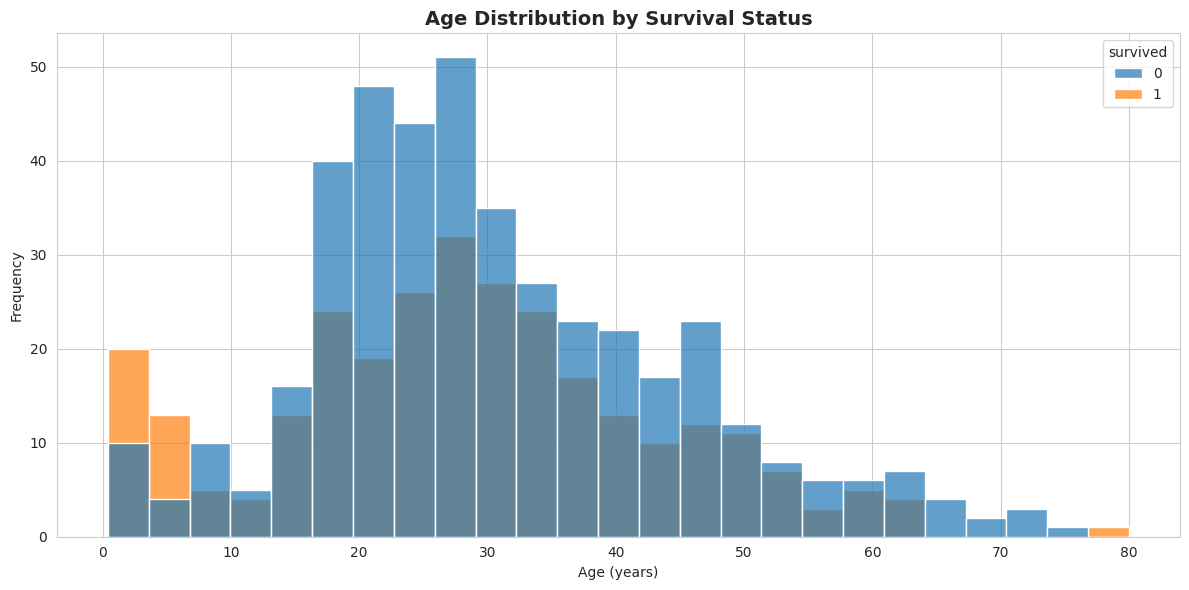

In [6]:
# Subtask 2.2: Histogram with Hue Parameter
# We use 'hue' to color the bars by survival status to see if certain age groups survived more
plt.figure(figsize=(12, 6))
sns.histplot(
    data=titanic,
    x="age",
    hue="survived",
    bins=25,
    alpha=0.7,
    multiple="layer" # Overlays the distributions for direct comparison
)

plt.title("Age Distribution by Survival Status", fontsize=14, fontweight="bold")
plt.xlabel("Age (years)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

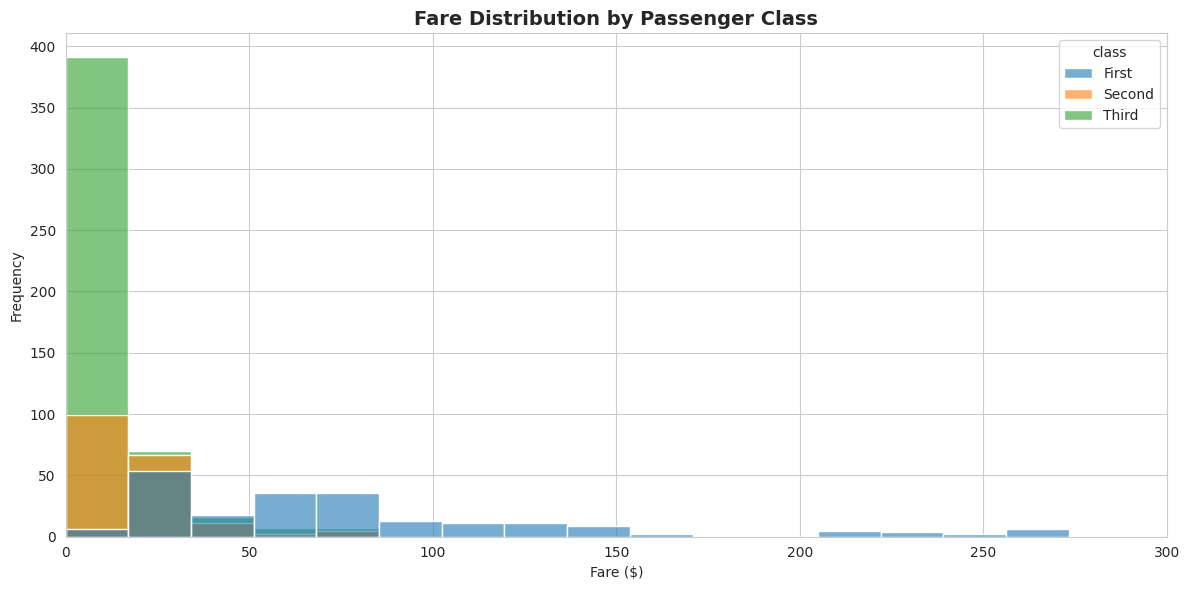

In [7]:
# Subtask 2.3: Histogram with Multiple Groupings
# Comparing fare distribution across ticket classes
plt.figure(figsize=(12, 6))
sns.histplot(
    data=titanic,
    x="fare",
    hue="class",
    bins=30,
    alpha=0.6,
    multiple="layer"
)

plt.title("Fare Distribution by Passenger Class", fontsize=14, fontweight="bold")
plt.xlabel("Fare ($)")
plt.ylabel("Frequency")
plt.xlim(0, 300)  # Limit x-axis to zoom in on the most common fare ranges
plt.tight_layout()
plt.show()

# Task 3: Creating Boxplots

### 🐣 ELI10: The "Summary" Chart
A boxplot shows us the middle of the data (the median), where most people fall, and the "weird" data points (outliers) that are much higher or lower than everyone else.

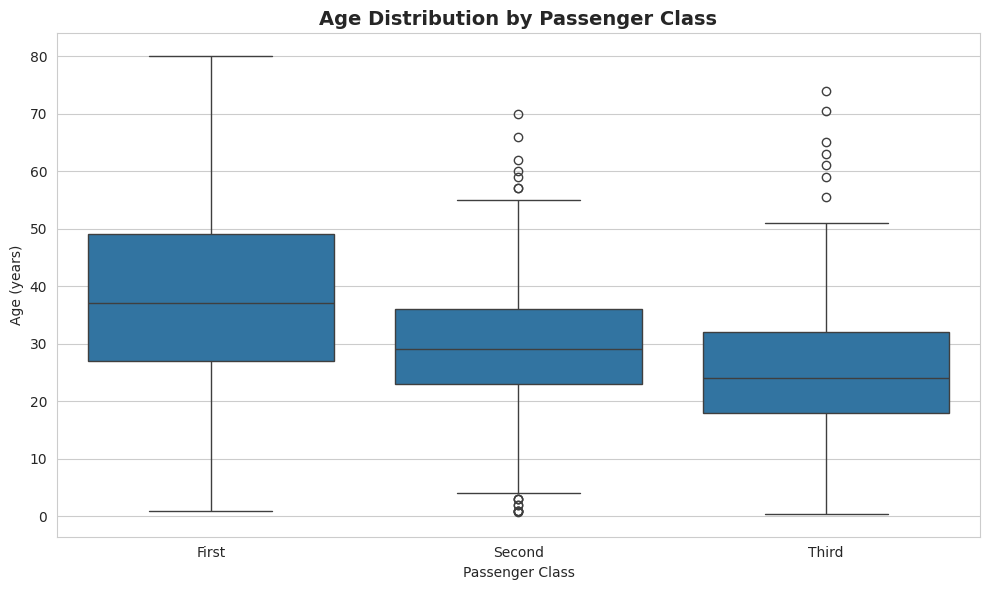

In [8]:
# Subtask 3.1: Basic Boxplot
# Comparing age distribution across passenger classes to see if richer passengers were older
plt.figure(figsize=(10, 6))
sns.boxplot(data=titanic, x="class", y="age")

plt.title("Age Distribution by Passenger Class", fontsize=14, fontweight="bold")
plt.xlabel("Passenger Class")
plt.ylabel("Age (years)")
plt.tight_layout()
plt.show()

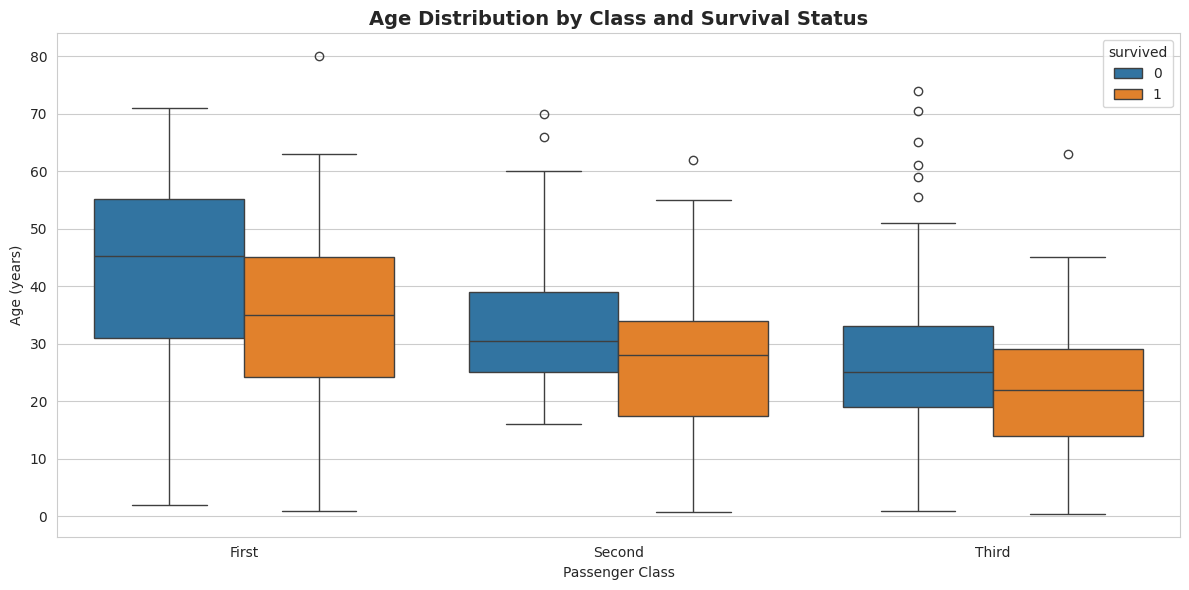

In [9]:
# Subtask 3.2: Boxplot with Hue Parameter
# Adding survival status to see the age spread of survivors vs non-survivors per class
plt.figure(figsize=(12, 6))
sns.boxplot(data=titanic, x="class", y="age", hue="survived")

plt.title("Age Distribution by Class and Survival Status", fontsize=14, fontweight="bold")
plt.xlabel("Passenger Class")
plt.ylabel("Age (years)")
plt.tight_layout()
plt.show()

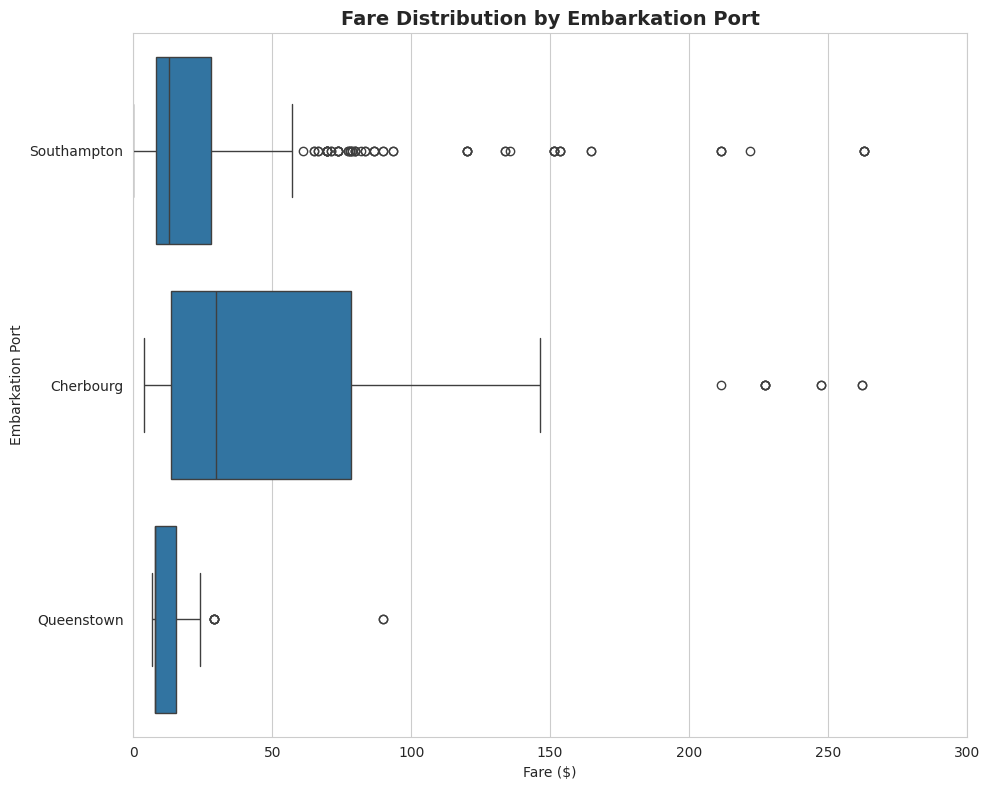

In [10]:
# Subtask 3.3: Horizontal Boxplot
# Useful when text labels on the y-axis are long
plt.figure(figsize=(10, 8))
sns.boxplot(data=titanic, y="embark_town", x="fare", orient="h")

plt.title("Fare Distribution by Embarkation Port", fontsize=14, fontweight="bold")
plt.xlabel("Fare ($)")
plt.ylabel("Embarkation Port")
plt.xlim(0, 300) # Clipping outliers for better visualization
plt.tight_layout()
plt.show()

# Task 4: Creating Violin Plots

### 🐣 ELI10: The "Shape" Chart
Violin plots are like boxplots, but they show the actual "shape" of the data. If the violin is fat in the middle, many people are that age. If it's skinny, very few are.

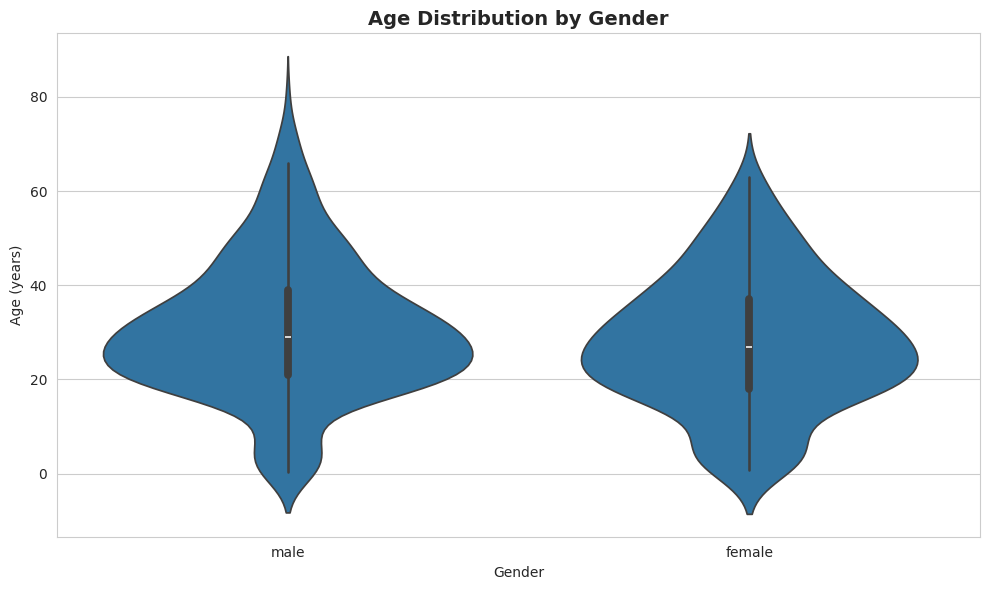

In [11]:
# Subtask 4.1: Basic Violin Plot
# Visualizing age distribution by gender
plt.figure(figsize=(10, 6))
sns.violinplot(data=titanic, x="sex", y="age")

plt.title("Age Distribution by Gender", fontsize=14, fontweight="bold")
plt.xlabel("Gender")
plt.ylabel("Age (years)")
plt.tight_layout()
plt.show()

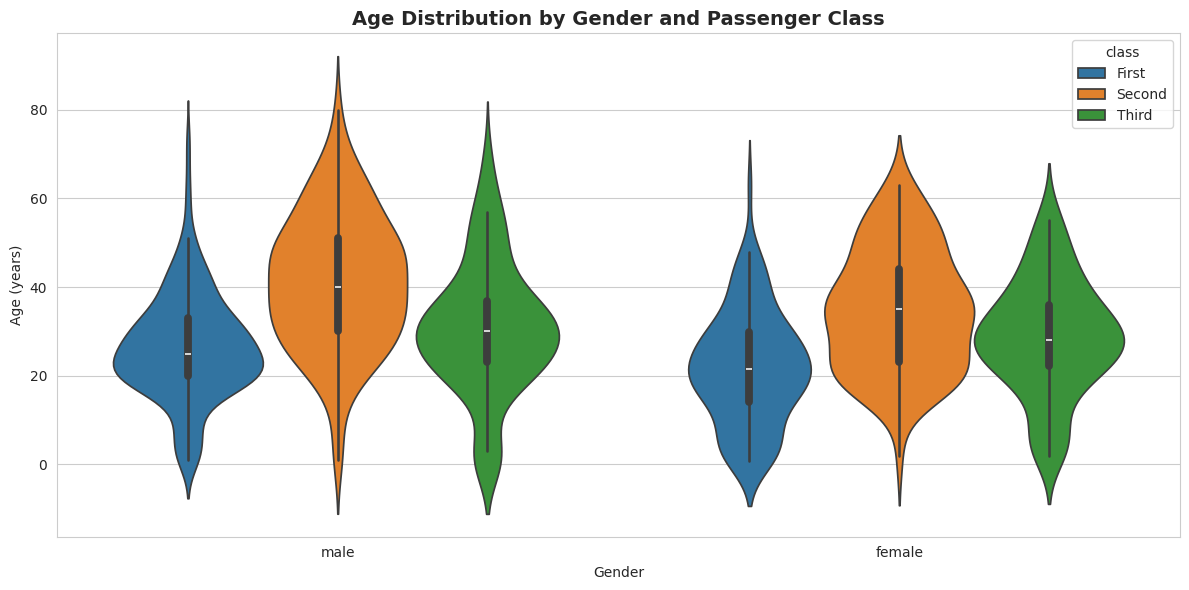

In [12]:
# Subtask 4.2: Violin Plot with Hue
# This shows age distribution for genders across different classes
plt.figure(figsize=(12, 6))
sns.violinplot(data=titanic, x="sex", y="age", hue="class")

plt.title("Age Distribution by Gender and Passenger Class", fontsize=14, fontweight="bold")
plt.xlabel("Gender")
plt.ylabel("Age (years)")
plt.tight_layout()
plt.show()

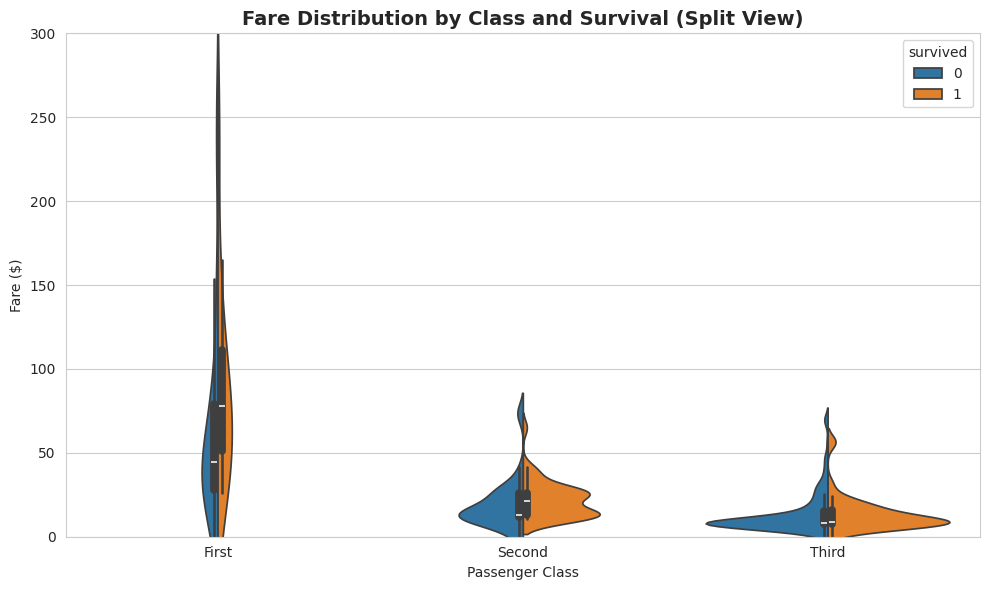

In [13]:
# Subtask 4.3: Split Violin Plot
# 'split=True' combines the two categories into one violin shape for easier comparison
plt.figure(figsize=(10, 6))
sns.violinplot(data=titanic, x="class", y="fare", hue="survived", split=True)

plt.title("Fare Distribution by Class and Survival (Split View)", fontsize=14, fontweight="bold")
plt.xlabel("Passenger Class")
plt.ylabel("Fare ($)")
plt.ylim(0, 300)
plt.tight_layout()
plt.show()

# Task 5: Using Row and Col Parameters for Subplots

### 🐣 ELI10: The "Grid" View
Sometimes one big chart is messy. We can use `row` and `col` to make a grid of small, simple charts side-by-side to compare things easily.

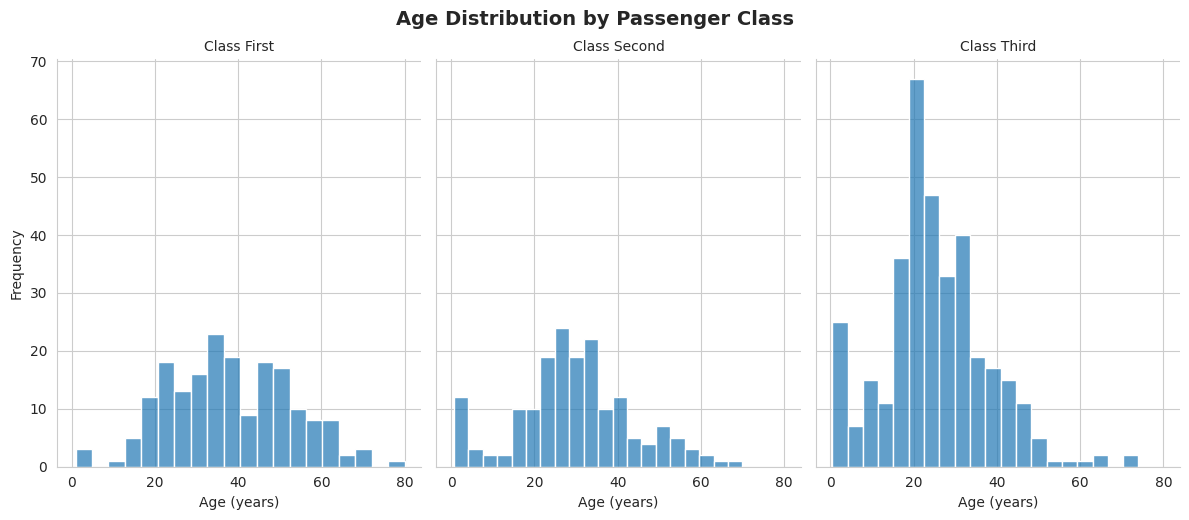

In [14]:
# Subtask 5.1: Using Col Parameter
# FacetGrid creates separate plots for each class horizontally
g = sns.FacetGrid(titanic, col="class", height=5, aspect=0.8)
g.map_dataframe(sns.histplot, x="age", bins=20, alpha=0.7)

g.set_axis_labels("Age (years)", "Frequency")
g.set_titles("Class {col_name}")
g.fig.suptitle("Age Distribution by Passenger Class", y=1.03, fontsize=14, fontweight="bold")
plt.show()

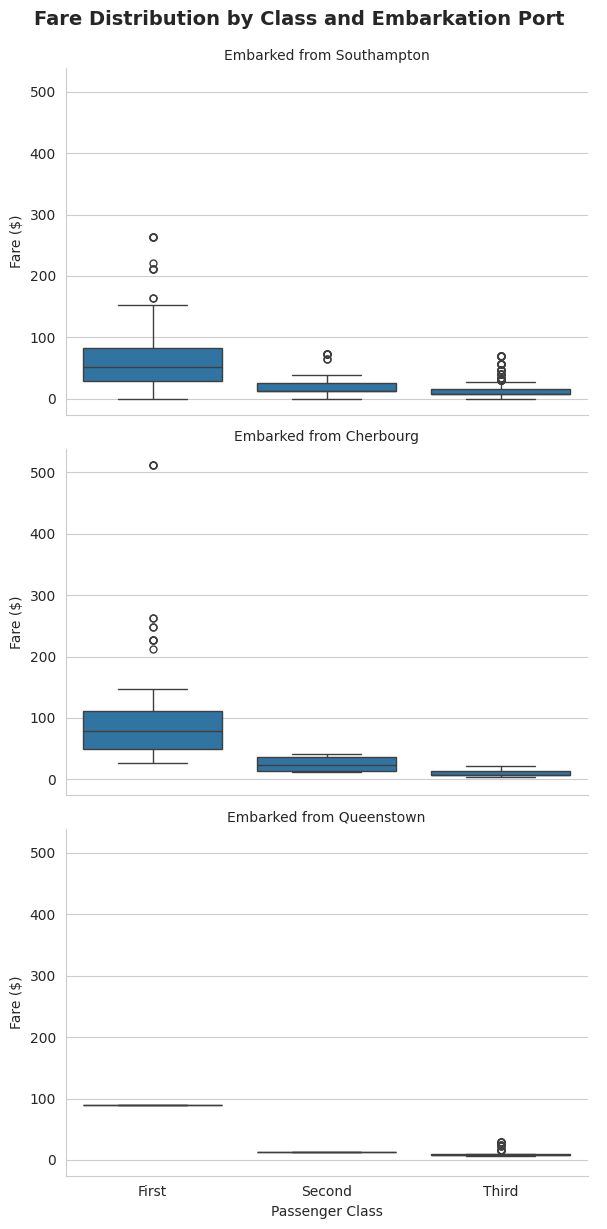

In [15]:
# Subtask 5.2: Using Row Parameter
# We use catplot(kind="box") for row-based grids to avoid layout errors
g = sns.catplot(
    data=titanic,
    x="class",
    y="fare",
    row="embark_town",
    kind="box",
    height=4,
    aspect=1.5
)

g.set_axis_labels("Passenger Class", "Fare ($)")
g.set_titles("Embarked from {row_name}")
g.fig.suptitle("Fare Distribution by Class and Embarkation Port", y=1.02, fontsize=14, fontweight="bold")
plt.show()

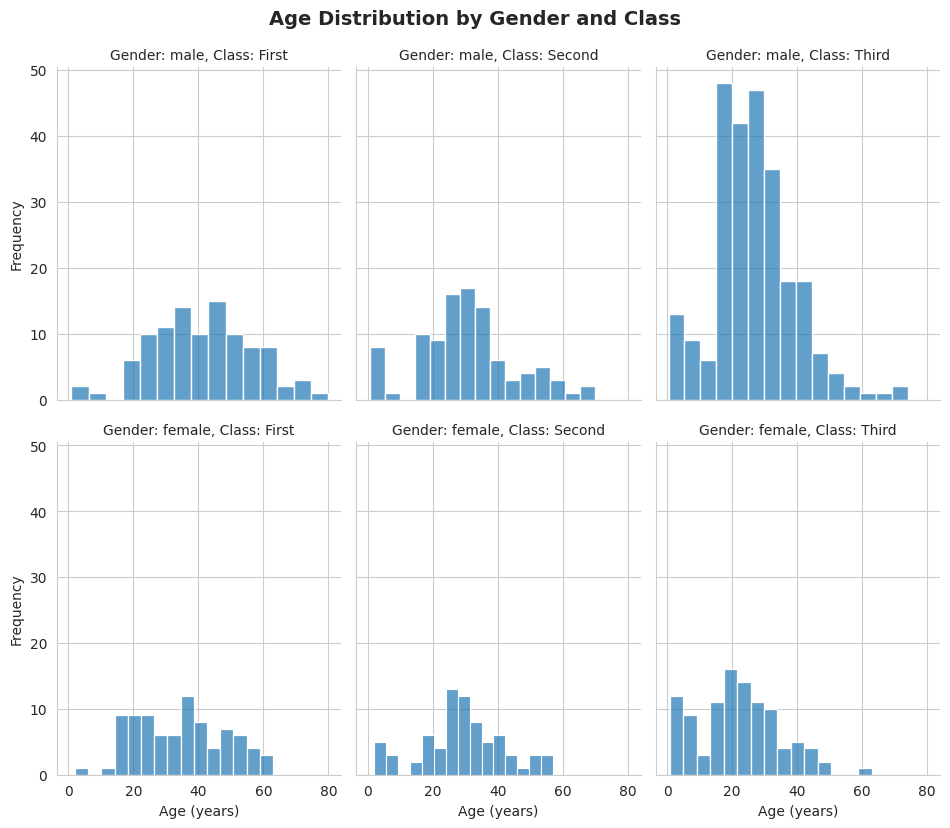

In [16]:
# Subtask 5.3: Using Both Row and Col
# Creating a matrix of plots: Gender (Rows) x Class (Cols)
g = sns.FacetGrid(titanic, row="sex", col="class", height=4, aspect=0.8)
g.map_dataframe(sns.histplot, x="age", bins=15, alpha=0.7)

g.set_axis_labels("Age (years)", "Frequency")
g.set_titles("Gender: {row_name}, Class: {col_name}")
g.fig.suptitle("Age Distribution by Gender and Class", y=1.03, fontsize=14, fontweight="bold")
plt.show()

# Task 6: Comprehensive Analysis Dashboard

### 🐣 ELI10: The Big Picture
Now we combine everything we've learned into one big dashboard to tell the full story of the Titanic.

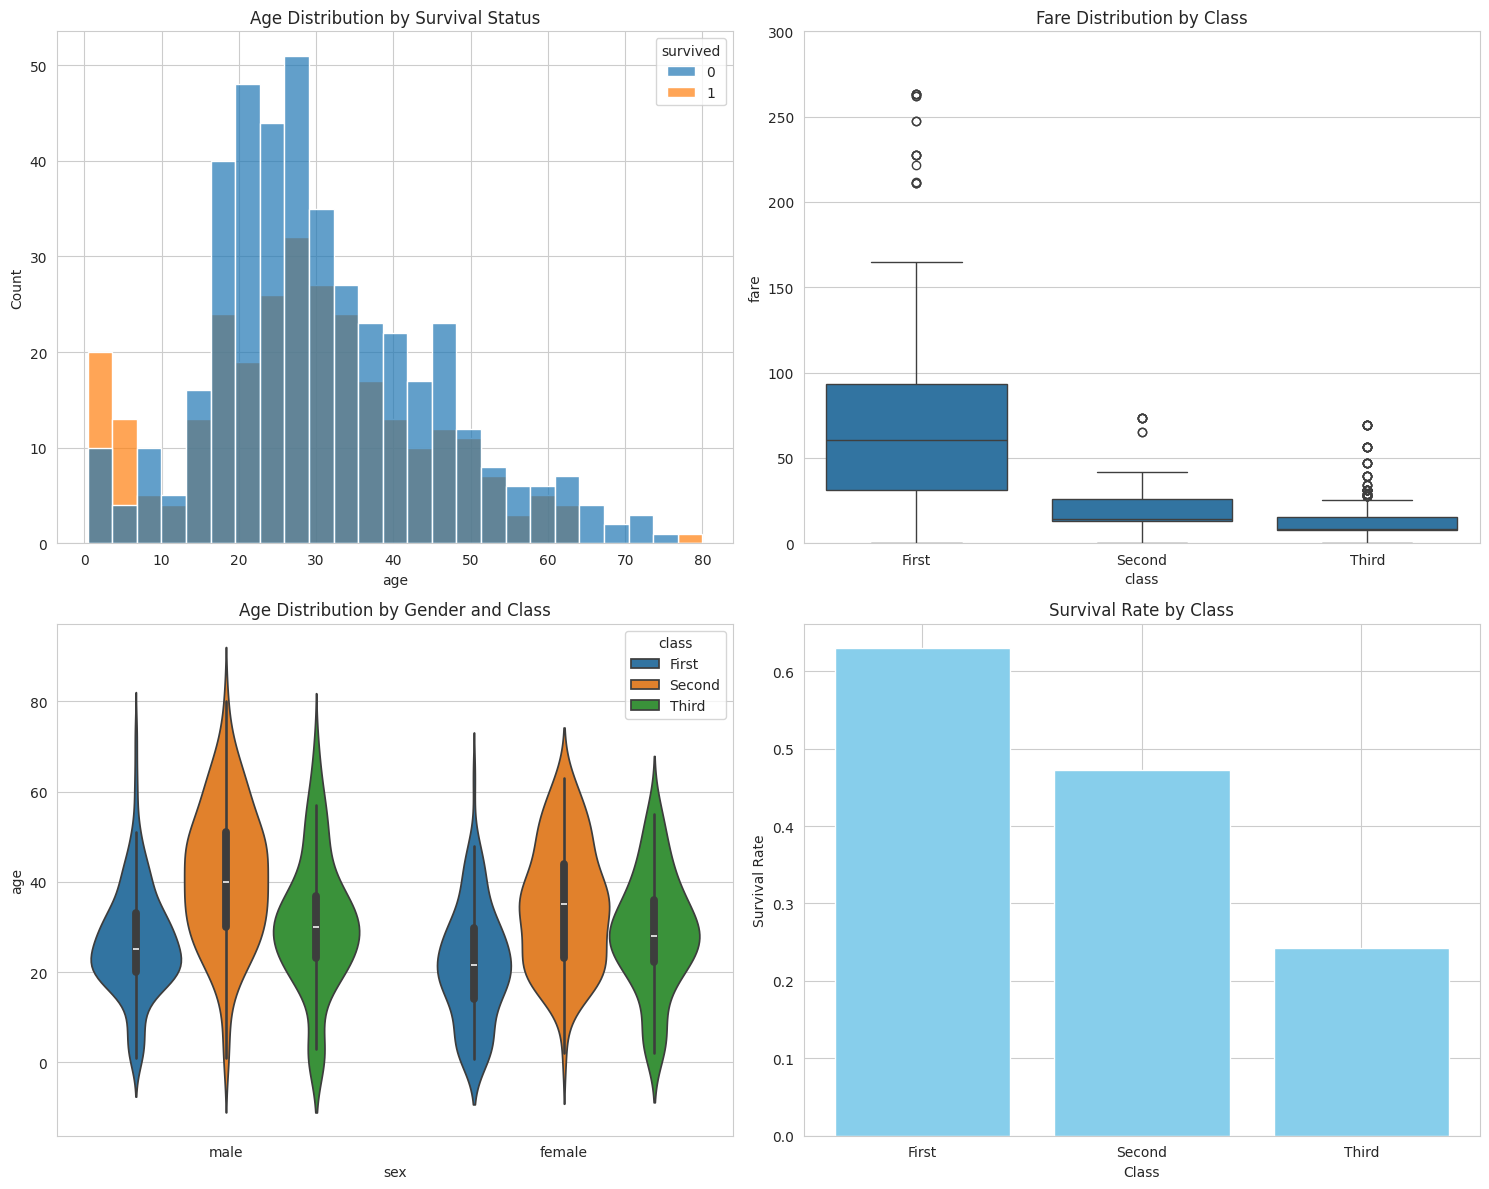

In [17]:
# Subtask 6.1: Multi-Plot Analysis Dashboard
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Age distribution by survival (Histogram)
sns.histplot(data=titanic, x="age", hue="survived", bins=25, alpha=0.7, ax=axes[0, 0])
axes[0, 0].set_title("Age Distribution by Survival Status")

# Plot 2: Fare boxplot by class (Boxplot)
sns.boxplot(data=titanic, x="class", y="fare", ax=axes[0, 1])
axes[0, 1].set_title("Fare Distribution by Class")
axes[0, 1].set_ylim(0, 300)

# Plot 3: Age violin plot by gender and class (Violin)
sns.violinplot(data=titanic, x="sex", y="age", hue="class", ax=axes[1, 0])
axes[1, 0].set_title("Age Distribution by Gender and Class")

# Plot 4: Survival rate by class (Manual Calculation and Bar Plot)
survival_by_class = titanic.groupby("class", observed=False)["survived"].mean()
axes[1, 1].bar(survival_by_class.index, survival_by_class.values, color="skyblue")
axes[1, 1].set_title("Survival Rate by Class")
axes[1, 1].set_ylabel("Survival Rate")
axes[1, 1].set_xlabel("Class")

plt.tight_layout()
plt.show()

In [18]:
# Subtask 6.2: Statistical Summary
# Printing out numbers to support what we see in the pictures
print("=== TITANIC DATASET ANALYSIS SUMMARY ===\n")

print("1. AGE ANALYSIS:")
print(f" - Average age: {titanic['age'].mean():.1f} years")
print(f" - Survivors average age: {titanic[titanic['survived'] == 1]['age'].mean():.1f} years")

print("\n2. FARE ANALYSIS:")
print(f" - Average fare: ${titanic['fare'].mean():.2f}")

print("\n3. SURVIVAL ANALYSIS:")
overall_survival = titanic["survived"].mean()
print(f" - Overall survival rate: {overall_survival:.1%}")

for gender in ["male", "female"]:
    survival_rate = titanic[titanic["sex"] == gender]["survived"].mean()
    print(f"   - {gender.capitalize()}: {survival_rate:.1%}")

=== TITANIC DATASET ANALYSIS SUMMARY ===

1. AGE ANALYSIS:
 - Average age: 29.7 years
 - Survivors average age: 28.3 years

2. FARE ANALYSIS:
 - Average fare: $32.20

3. SURVIVAL ANALYSIS:
 - Overall survival rate: 38.4%
   - Male: 18.9%
   - Female: 74.2%


# Task 7: Troubleshooting and Best Practices

### 🛠 Dealing with Missing Data
Data is often "messy." For example, we don't know the age of every passenger. We must handle these missing values so they don't break our charts.

In [19]:
# Check missing values
print("Missing data summary:")
print(titanic.isnull().sum())

# Create a cleaned version for plots involving age to avoid warnings
titanic_clean = titanic.dropna(subset=["age"])
print(f"\nRows after removing missing age values: {len(titanic_clean)}")

Missing data summary:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Rows after removing missing age values: 714


### 🎨 Best Practices for Polished Notebooks
1. **Rotate labels** if they overlap.
2. **Customize colors** for accessibility or branding.
3. **Save your work** as high-quality images.

/tmp/ipykernel_5823/1041111443.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=titanic, x="class", y="age", palette=custom_palette)


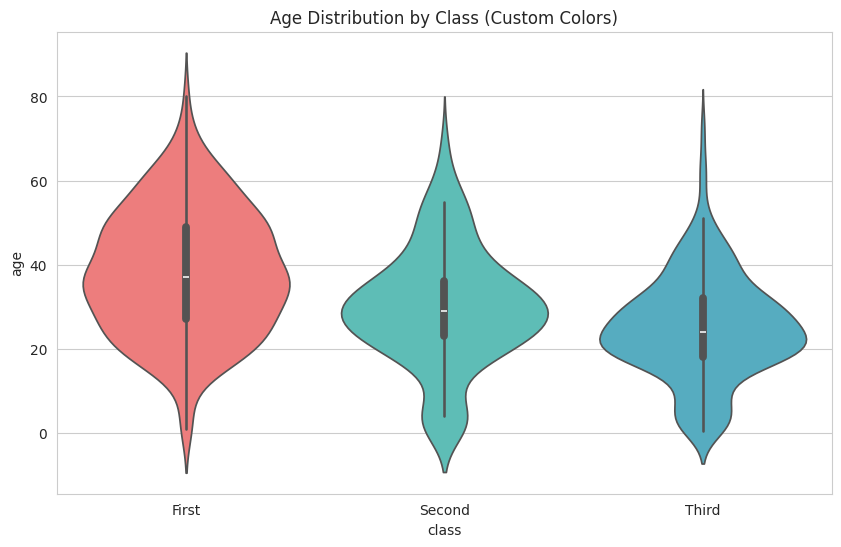

In [20]:
# Example: High-quality save and custom palette
plt.figure(figsize=(10, 6))
custom_palette = ["#FF6B6B", "#4ECDC4", "#45B7D1"]
sns.violinplot(data=titanic, x="class", y="age", palette=custom_palette)
plt.title("Age Distribution by Class (Custom Colors)")

# Save the plot for a report
plt.savefig("titanic_analysis_final.png", dpi=300, bbox_inches="tight")
plt.show()

## ✅ Verification Checklist
* [ ] Imported Seaborn, pandas, Matplotlib, and NumPy
* [ ] Loaded Titanic dataset from Seaborn
* [ ] Created histograms (Subtask 2.1)
* [ ] Used `hue` for categories (Subtask 2.2)
* [ ] Created boxplots for outliers (Subtask 3.1)
* [ ] Created violin plots for density (Subtask 4.1)
* [ ] Built subplot grids with `row` and `col` (Task 5)
* [ ] Created a dashboard (Task 6)

## 🛠 Troubleshooting Guide
* **Titanic dataset not loading?** Ensure internet access or run `%pip install seaborn` again.
* **Overlapping labels?** Use `plt.xticks(rotation=45)` or `plt.tight_layout()`.
* **FacetGrid error?** Always use `map_dataframe` instead of `map` for newer Seaborn versions.

## 📚 Key Concepts Summary
* **Histogram:** Shows frequency/distribution of numerical values.
* **Boxplot:** Shows summary statistics (median, quartiles) and outliers.
* **Violin Plot:** Combines boxplot summary with a distribution density shape.
* **Hue/Row/Col:** Parameters used to split data into sub-groups for better comparison.

## 🎓 Conclusion
Congratulations! You have successfully completed **Lab 22: Statistical Visuals with Seaborn**. You have mastered the art of statistical visualization, allowing you to tell complex data stories with simple, beautiful charts.

### What I Learned / Key Takeaways
* Visualization is key to identifying patterns that numbers alone might hide.
* Seaborn makes it easy to add layers of complexity (like gender and class) with simple parameters.
* Handling missing data is a critical first step in any analysis.

### Real-World Importance
These skills are used every day by Data Scientists to detect fraud in finance, analyze patient records in healthcare, and optimize marketing campaigns by understanding customer demographics.